In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
# from scipy.signal import TransferFunction, tf2zpk

In [2]:
def generate_psd(f, cutoff, n, turb_power, noise_power):
    f_safe = np.maximum(f, f[0])
    if n == 1:
        psd_turb = np.where(f_safe <= cutoff, (f_safe / cutoff)**(-2/3), (f_safe / cutoff)**(-17/3))
    else:
        psd_turb = np.where(f_safe <= cutoff, 1.0, (f_safe / cutoff)**(-17/3))
        
    df = np.gradient(f)
    f_s = f[-1] * 2 
    sinc_filter = np.sinc(f_safe / f_s)**2 
    psd_turb *= sinc_filter
    
    psd_turb *= (turb_power / np.sum(psd_turb * df))
    
    psd_noise = np.ones_like(f)
    psd_noise *= (noise_power / np.sum(psd_noise * df))
    
    return psd_turb, psd_noise

def eval_tf(b, a, f, f_s):
    z_inv = np.exp(-1j * 2 * np.pi * f / f_s)
    num = sum(b[k] * (z_inv**k) for k in range(len(b)))
    den = sum(a[k] * (z_inv**k) for k in range(len(a)))
    return num / den

def is_stable(a):
    roots = np.roots(a)
    return np.all(np.abs(roots) < 0.9999)

def pre_fit_controller(order, f, psd_turb, f_s):
    target_mag = np.sqrt(psd_turb)
    target_mag /= np.max(target_mag)
    
    def loss(params):
        b = params[:order+1]
        a = np.insert(params[order+1:], 0, 1.0)
        if not is_stable(a): return 1e6
        C = eval_tf(b, a, f, f_s)
        return np.sum((np.abs(C) - target_mag)**2)

    init_b = np.zeros(order + 1); init_b[0] = 0.1
    init_a = np.zeros(order); init_a[0] = -0.9
    init_params = np.concatenate([init_b, init_a])

    res = minimize(loss, init_params, method='Nelder-Mead', options={'maxiter': 5000})
    b_guess = res.x[:order+1]
    a_guess = np.insert(res.x[order+1:], 0, 1.0)
    return b_guess, a_guess

def cost_function(params, order, f, psd_turb, psd_noise, N, f_s, og=1.0):
    b = params[:order+1]
    a = np.insert(params[order+1:], 0, 1.0)
    if not is_stable(a): return 1e9 

    C = eval_tf(b, a, f, f_s)
    P = np.exp(-1j * 2 * np.pi * f * N / f_s)
    H_ol = C * P
    denom = 1.0 + H_ol*og
    if np.min(np.abs(denom)) < 1e-4: return 1e9

    RTF = 1.0 / denom
    NTF = H_ol / denom
    psd_res = (np.abs(RTF)**2 * psd_turb) + (np.abs(NTF)**2 * psd_noise)
    return np.sum(psd_res * np.gradient(f))

def optimize_higher_order_scao(orders=[1, 2, 3], turb_power=100.0, noise_power=0.5, og=1.0,
                               delay_steps=1.5, loop_freq=1000.0, cutoff=15.0, n=1, restarts:int=100):
    
    f_s = loop_freq
    f = np.linspace(0.1, f_s/2.0, 2000)
    psd_turb, psd_noise = generate_psd(f, cutoff, n, turb_power, noise_power)
    
    plt.figure(figsize=(16, 6))
    
    plt.subplot(1, 2, 1)
    plt.loglog(f, psd_turb/psd_noise, label=f'Turbulence PSD (n={n})')
    plt.loglog(f, psd_noise/psd_noise, '--',label='Noise Floor')
    
    plt.subplot(1, 2, 2)
    plt.loglog(f, psd_turb, label='Uncorrected Turb')
    plt.loglog(f, psd_noise, '--', label='Noise floor')
    
    colors = ['green', 'orange', 'purple']
    
    for i, order in enumerate(orders):
        b_guess, a_guess = pre_fit_controller(order, f, psd_turb, f_s)
        init_params = np.concatenate([b_guess, a_guess[1:]])
        
        res = minimize(cost_function, init_params, 
                       args=(order, f, psd_turb, psd_noise, delay_steps, f_s, og),
                       method='Nelder-Mead', 
                       options={'maxiter': 5000, 'adaptive': True})
        
        best_b = res.x[:order+1]
        best_a = np.insert(res.x[order+1:], 0, 1.0)
        
        C = eval_tf(best_b, best_a, f, f_s)
        P = np.exp(-1j * 2 * np.pi * f * delay_steps / f_s)
        H_ol = C * P
        den = 1.0 + H_ol*og
        RTF = 1.0 / den
        NTF = H_ol / den
        
        psd_res = (np.abs(RTF)**2 * psd_turb) + (np.abs(NTF)**2 * psd_noise)
        min_variance = np.sum(psd_res * np.gradient(f))
        
        print(f"Order {order}:")
        print(f" B coefficients: {best_b}")
        print(f" A coefficients: {best_a}")
        print(f" Residual Variance: {min_variance:.4e}\n")
        
        plt.subplot(1, 2, 1)
        plt.loglog(f, 1.0/(np.abs(RTF)**2), label=r'$|RTF|^-2$'+f' (Order {order})')
        plt.subplot(1, 2, 2)
        plt.loglog(f, psd_res, label=f'Residual (Order {order})')

    plt.subplot(1, 2, 1)
    plt.title(f"Spectral SNR")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power / Amplitude")
    plt.grid(True, which="both", alpha=0.5)
    plt.legend()
    plt.xlim(f[0], f[-1])
    plt.ylim([1e-2,psd_turb[0]/psd_noise[0]*4])
    
    plt.subplot(1, 2, 2)
    plt.title(f"Residual PSD")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power Spectral Density")
    plt.grid(True, which="both", alpha=0.5)
    plt.legend()
    plt.xlim(f[0], f[-1])
    plt.ylim([1e-2*psd_noise[0],psd_turb[0]*4])

    plt.tight_layout()
    


Order 1:
 B coefficients: [ 0.51193927 -0.09710994]
 A coefficients: [ 1.        -0.9981696]
 Residual Variance: 4.1031e+00

Order 2:
 B coefficients: [5.44683417e-01 1.75127114e-05 4.47148136e-02]
 A coefficients: [ 1.         -0.60567798 -0.39171749]
 Residual Variance: 4.0100e+00

Order 3:
 B coefficients: [ 0.3493562  -0.36046578 -0.08372532  0.12855942]
 A coefficients: [ 1.         -2.24271309  1.49612425 -0.25301681]
 Residual Variance: 1.0891e+00



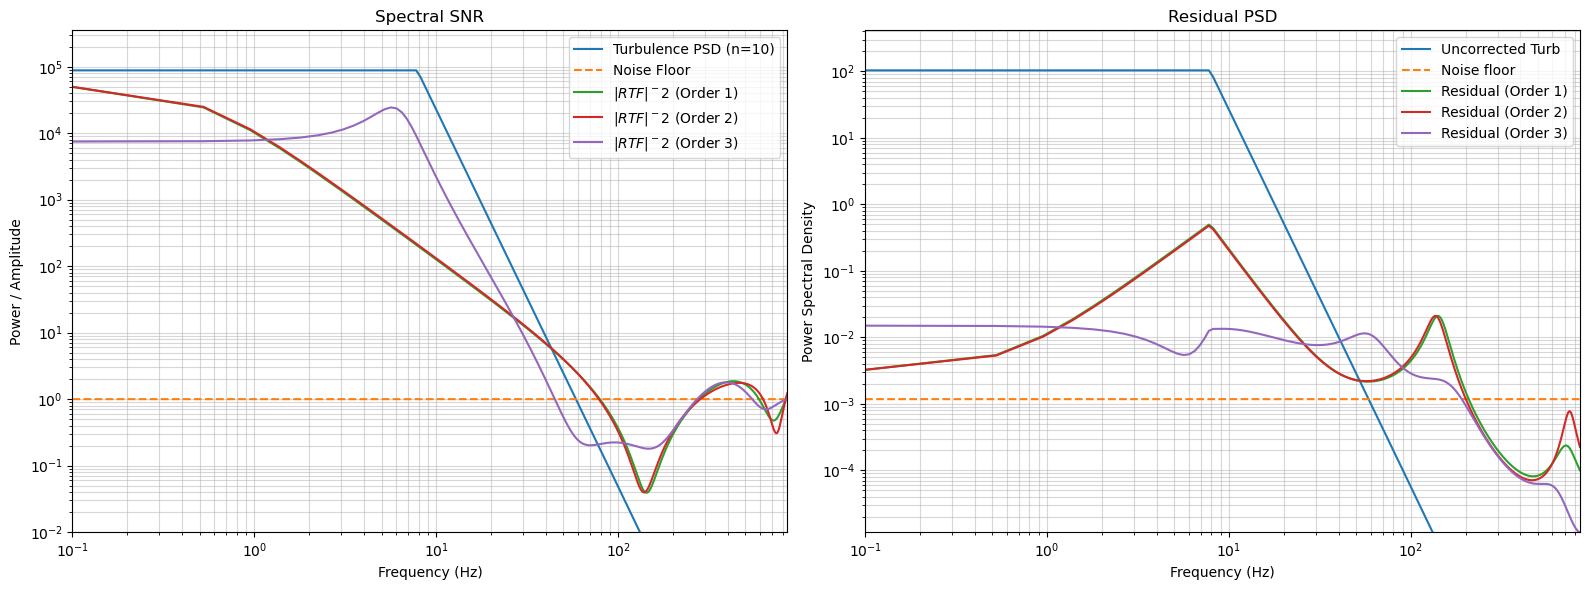

In [6]:
D = 8.4 #1.82 #
v = 20.0 
n = 10
f_break_n2 = 0.3 * (n + 1) * v / D 
f = 1700 #1000 #
delay = 3.5
opt_gain=1.0

# Keeping SNR = 100 for consistency with the last run
optimize_higher_order_scao(
    orders=[1, 2, 3],
    turb_power=1000.0,
    noise_power=1.0,
    delay_steps=delay,
    loop_freq=f,
    cutoff=f_break_n2,
    n=n,
    og=opt_gain
)